In [ ]:
## VLM EXPERIMENT CONFIGURATION

SEED = 42

IMG_SIZE = 224
MAX_LENGTH = 32

BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 10

N_EMBD = 128
N_HEAD = 12
N_LAYER = 12
DROPOUT = 0.8

PATCH_SIZE = 16
IMAGE_EMBED_DIM = 768

EVAL_INTERVAL = 10

print("Configuration Loaded")


Configuration Loaded


In [ ]:
import random
import numpy as np
import torch


def set_Seed(seed = 42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)

  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_Seed(SEED)

print("Seed: " , SEED)
print("PyTorch:" , torch.__version__)
print("CUDA available: " , torch.cuda.is_available())

if torch.cuda.is_available():
  print("GPU" , torch.cuda.get_device_name(0))



Seed:  42
PyTorch: 2.11.0+cu128
CUDA available:  True
GPU NVIDIA L4


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
DATA_DIR = "/content/drive/MyDrive/Image_Caption"

CSV_PATH = os.path.join(DATA_DIR ,"captions.txt")
IMAGE_DIR = os.path.join(DATA_DIR , "Images")

In [ ]:
df = pd.read_csv(
    CSV_PATH,
    sep = ","
)

print("Dataset Loaded Successfully")
print("Number of rows: " , len(df))
print("Columns" , df.columns.tolist())

Dataset Loaded Successfully
Number of rows:  40455
Columns ['image', 'caption']


In [ ]:
df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [ ]:
df.isna().sum()

,0
image,0
caption,0


In [ ]:
df.duplicated().sum()

np.int64(10)

In [ ]:
df["caption"].nunique()

40201

In [ ]:
# Use all available images
unique_images = df["image"].unique()

print("Unique images:", len(unique_images))
print("Total caption rows:", len(df))

Unique images: 8091
Total caption rows: 40455


In [ ]:
df["image_path"] = df["image"].apply(lambda x: os.path.join(IMAGE_DIR,x))

df["image_exists"] = df["image_path"].apply(os.path.exists)

print("images Found: " , df["image_exists"].sum())
print("image Missing" , (~df["image_exists"]).sum())

images Found:  40455
image Missing 0


(375, 500)
RGB


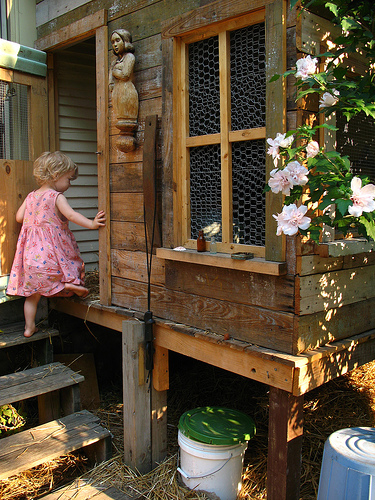

In [ ]:
sample = df.iloc[1]

image = Image.open(sample["image_path"])

print(image.size)
print(image.mode)

display(image)

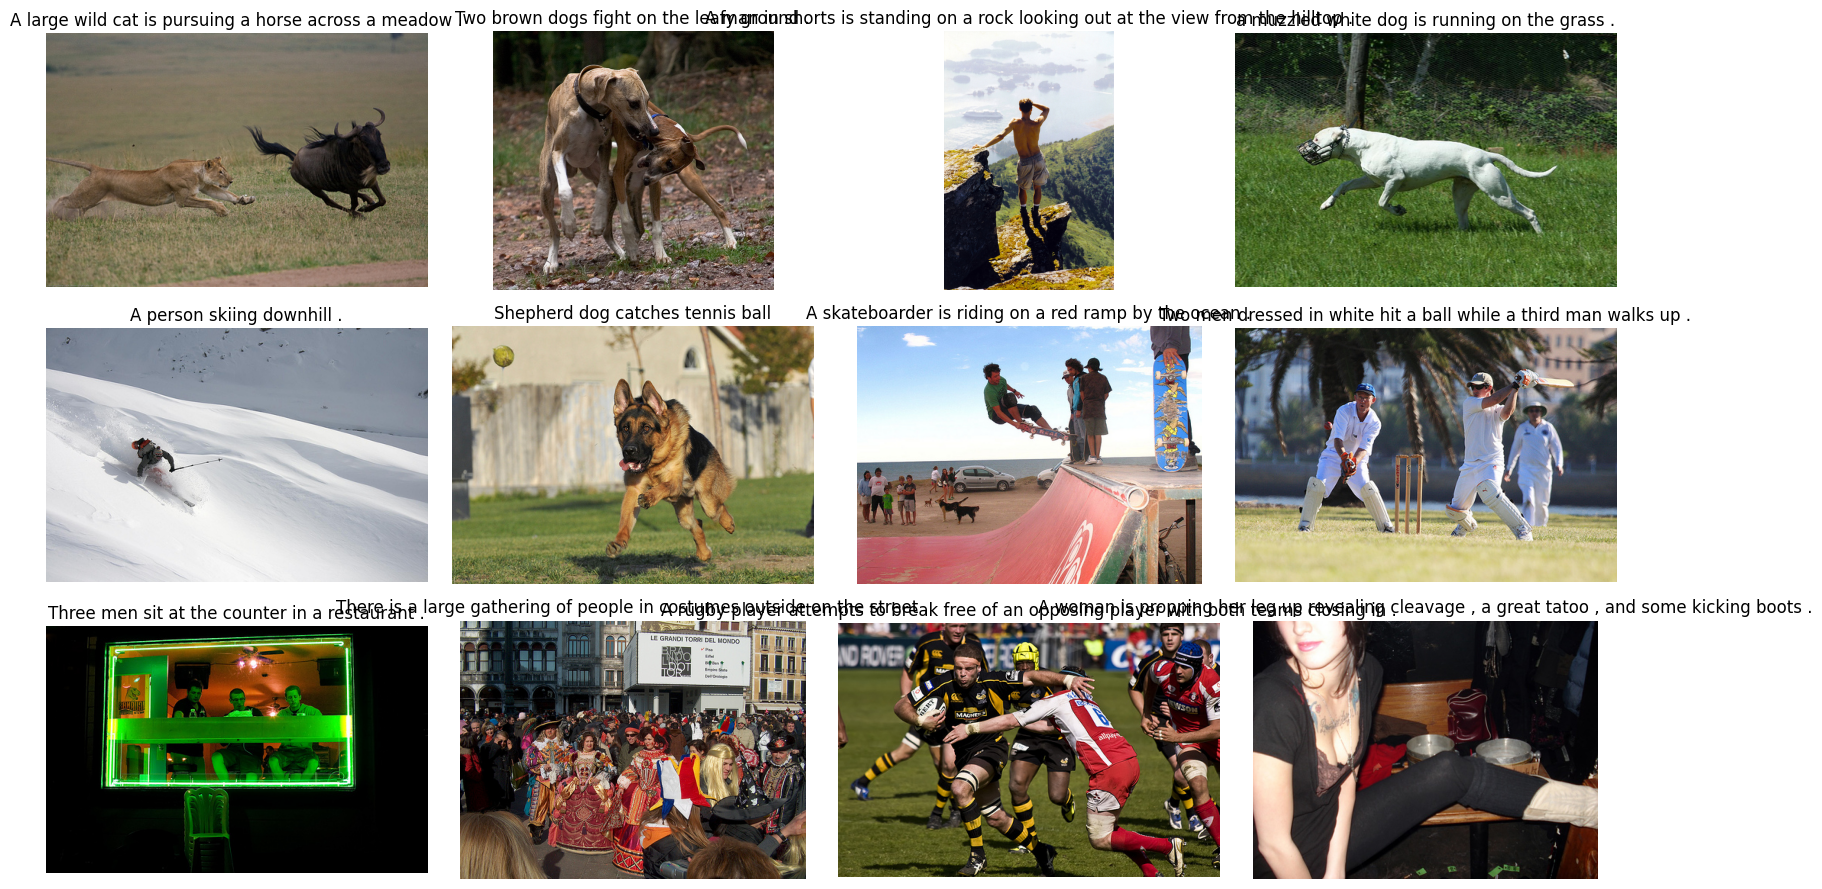

In [ ]:
fig , axes = plt.subplots(3,4 , figsize = (16,9))

for ax , (_ , row) in zip(axes.flat , df.sample(12 , random_state =SEED).iterrows()):

  image = Image.open(row["image_path"]).convert("RGB")

  ax.imshow(image)
  ax.set_title(row["caption"])
  ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
print("Total Samples: ", len(df))

Total Samples:  40455


In [ ]:
for i , caption in enumerate(df["caption"]):
  print(f"{i:02d} : {caption}")

00 : A child in a pink dress is climbing up a set of stairs in an entry way .
01 : A girl going into a wooden building .
02 : A little girl climbing into a wooden playhouse .
03 : A little girl climbing the stairs to her playhouse .
04 : A little girl in a pink dress going into a wooden cabin .
05 : A black dog and a spotted dog are fighting
06 : A black dog and a tri-colored dog playing with each other on the road .
07 : A black dog and a white dog with brown spots are staring at each other in the street .
08 : Two dogs of different breeds looking at each other on the road .
09 : Two dogs on pavement moving toward each other .
10 : A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
11 : A little girl is sitting in front of a large painted rainbow .
12 : A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .
13 : There is a girl with pigtails sitting in front of a rainbow painting .
14 : Young girl w

In [ ]:
df["caption_words"] = df["caption"].str.split().str.len()

print(df["caption_words"].describe())

count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_words, dtype: float64


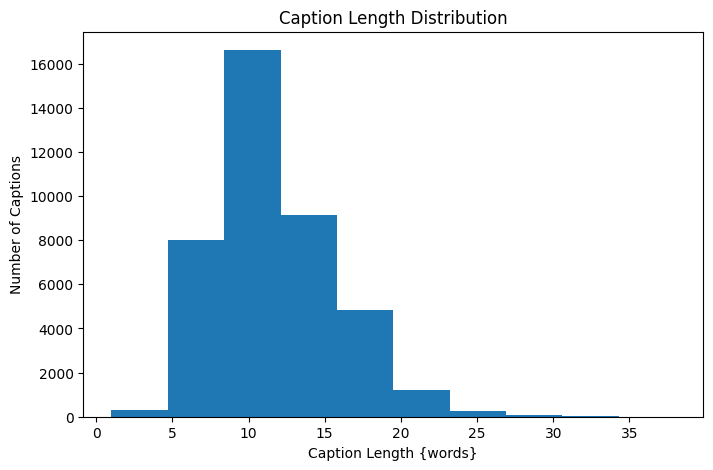

In [ ]:
plt.figure(figsize= (8,5))

plt.hist(df["caption_words"] , bins=10)

plt.xlabel("Caption Length {words}")
plt.ylabel("Number of Captions")
plt.title("Caption Length Distribution")

plt.show()

In [ ]:
from transformers import LlamaTokenizer

tokenizer = LlamaTokenizer.from_pretrained("NousResearch/Llama-2-7b-chat-hf")

token_length = []

for caption in df["caption"]:
  tokens = tokenizer(
      caption ,
      add_special_tokens = False
  )["input_ids"]

  token_length.append(len(tokens))


df["caption_tokens"] = token_length

print(df[["caption" , "caption_words" , "caption_tokens"]])

tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

                                                 caption  caption_words  \
0      A child in a pink dress is climbing up a set o...             18   
1                  A girl going into a wooden building .              8   
2       A little girl climbing into a wooden playhouse .              9   
3      A little girl climbing the stairs to her playh...             10   
4      A little girl in a pink dress going into a woo...             13   
...                                                  ...            ...   
40450           A man in a pink shirt climbs a rock face             10   
40451           A man is rock climbing high in the air .             10   
40452  A person in a red shirt climbing up a rock fac...             16   
40453                    A rock climber in a red shirt .              8   
40454  A rock climber practices on a rock climbing wa...             10   

       caption_tokens  
0                  21  
1                   8  
2                  11  
3  

In [ ]:
caption_token_lengths = []

for caption in df["caption"]:
    ids = tokenizer(
        caption,
        add_special_tokens=False
    )["input_ids"]

    caption_token_lengths.append(len(ids))

caption_lengths = pd.Series(caption_token_lengths)

print(caption_lengths.describe())

count    40455.000000
mean        13.966012
std          4.703899
min          1.000000
25%         11.000000
50%         13.000000
75%         17.000000
max         48.000000
dtype: float64


In [ ]:
from collections import Counter

word_counter = Counter()

for caption in df["caption"]:
  word_counter.update(caption.lower().split())

print("Vocabulary Size: " , len(word_counter))

for word , count in word_counter.most_common(20):
  print(f" {word:15s} {count}")

Vocabulary Size:  8918
 a               62986
 .               36577
 in              18974
 the             18418
 on              10743
 is              9345
 and             8851
 dog             8136
 with            7765
 man             7265
 of              6713
 two             5638
 white           3940
 black           3832
 boy             3581
 are             3504
 woman           3402
 girl            3328
 ,               3232
 to              3173


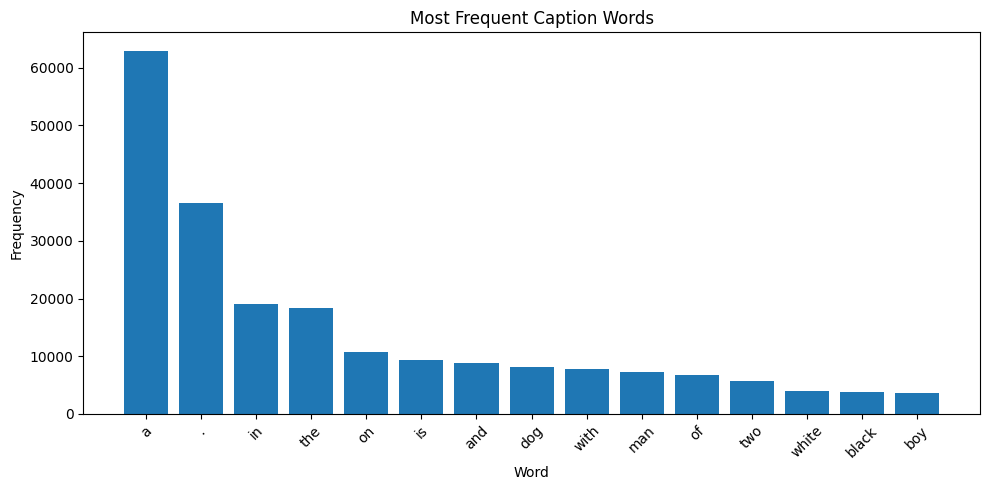

In [ ]:
words, counts = zip(*word_counter.most_common(15))

plt.figure(figsize=(10, 5))

plt.bar(words, counts)

plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Most Frequent Caption Words")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
print(type(tokenizer))
print(len(tokenizer))
print(tokenizer.bos_token_id)
print(tokenizer.eos_token_id)
print(tokenizer.pad_token_id)
print(tokenizer.unk_token_id)

<class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>
32001
1
2
0
0


In [ ]:
caption = df["caption"][0]

tokens = tokenizer.tokenize(caption)

ids = tokenizer.convert_tokens_to_ids(tokens)

print(caption)
print(tokens)
print(ids)

A child in a pink dress is climbing up a set of stairs in an entry way .
['▁A', '▁child', '▁in', '▁a', '▁p', 'ink', '▁dress', '▁is', '▁clim', 'bing', '▁up', '▁a', '▁set', '▁of', '▁st', 'airs', '▁in', '▁an', '▁entry', '▁way', '▁.']
[319, 2278, 297, 263, 282, 682, 10714, 338, 10784, 10549, 701, 263, 731, 310, 380, 7121, 297, 385, 6251, 982, 869]


In [ ]:
encoded = tokenizer(
    caption,
    add_special_tokens = True
)

print(encoded)

{'input_ids': [1, 319, 2278, 297, 263, 282, 682, 10714, 338, 10784, 10549, 701, 263, 731, 310, 380, 7121, 297, 385, 6251, 982, 869], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
print(tokenizer.eos_token , tokenizer.eos_token_id)
print(tokenizer.bos_token , tokenizer.bos_token_id)
print(tokenizer.pad_token , tokenizer.pad_token_id)
print(tokenizer.unk_token , tokenizer.unk_token_id)

print(tokenizer.special_tokens_map)

</s> 2
<s> 1
<unk> 0
<unk> 0
{'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<unk>'}


In [ ]:
caption = "red car"

print("\nWithout special tokens:")
print(tokenizer(caption, add_special_tokens=False))

print("\nWith special tokens:")
print(tokenizer(caption, add_special_tokens=True))



Without special tokens:
{'input_ids': [2654, 1559], 'attention_mask': [1, 1]}

With special tokens:
{'input_ids': [1, 2654, 1559], 'attention_mask': [1, 1, 1]}


In [ ]:
tokenizer.add_special_tokens({
    "pad_token" : "<pad>"
})

1

In [ ]:
print(tokenizer.pad_token)
print(tokenizer.pad_token_id)
print(len(tokenizer))

<unk>
0
32001


In [ ]:
caption = "red car"

print("\nWithout special tokens:")
print(tokenizer(caption, add_special_tokens=False))

print("\nWith special tokens:")
print(tokenizer(caption, add_special_tokens=True))



Without special tokens:
{'input_ids': [2654, 1559], 'attention_mask': [1, 1]}

With special tokens:
{'input_ids': [1, 2654, 1559], 'attention_mask': [1, 1, 1]}


In [ ]:
prompt = "A photo of"
caption = "A child in a pink dress is climbing up a set of stairs in an entry way ."

prompt_ids = tokenizer(
    prompt,
    add_special_tokens = True
)["input_ids"]

caption_ids = tokenizer(
    caption,
    add_special_tokens= False
)["input_ids"]

input_ids = prompt_ids + caption_ids + [tokenizer.eos_token_id]

print(prompt_ids)
print(caption_ids)
print(input_ids)

[1, 319, 15373, 310]
[319, 2278, 297, 263, 282, 682, 10714, 338, 10784, 10549, 701, 263, 731, 310, 380, 7121, 297, 385, 6251, 982, 869]
[1, 319, 15373, 310, 319, 2278, 297, 263, 282, 682, 10714, 338, 10784, 10549, 701, 263, 731, 310, 380, 7121, 297, 385, 6251, 982, 869, 2]


In [ ]:
print(tokenizer.decode(input_ids , skip_special_tokens = False))

<s> A photo of A child in a pink dress is climbing up a set of stairs in an entry way .</s>


In [ ]:
max_length = 32

pad_id = tokenizer.pad_token_id
eos_id = tokenizer.eos_token_id

input_ids = prompt_ids + caption_ids + [eos_id]

padding_length = max_length - len(input_ids)

input_ids = input_ids + [pad_id] * padding_length

attention_mask = [1] * (max_length - padding_length) + [0] * padding_length

print(input_ids)

print(attention_mask)

[1, 319, 15373, 310, 319, 2278, 297, 263, 282, 682, 10714, 338, 10784, 10549, 701, 263, 731, 310, 380, 7121, 297, 385, 6251, 982, 869, 2, 32000, 32000, 32000, 32000, 32000, 32000]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]


##Preparing DataSet

In [ ]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

In [ ]:
class ImageCaptionDataset(Dataset):

  def __init__(self , df , image_dir , tokenizer , image_transform, prompt = "A photo of" , max_length = 32):
    self.df = df.reset_index(drop = True)
    self.image_dir = IMAGE_DIR
    self.tokenizer = tokenizer
    self.image_transform = image_transform
    self.prompt = prompt
    self.max_length = max_length

  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):

    row = self.df.iloc[idx]

    ##Load Image

    image_path = os.path.join(
        self.image_dir,
        row["image"]
    )

    image = Image.open(image_path).convert("RGB")

    image = self.image_transform(image)

    prompt_ids = self.tokenizer(
        self.prompt,
        add_special_tokens = True
    )["input_ids"]

    caption_ids = self.tokenizer(
        row["caption"],
        add_special_tokens = False
    )["input_ids"]

    input_ids = prompt_ids _ caption_ids

    input_ids = input_ids[:self.max_length]

    sequence_length = len(input_ids)

    padding_length = self.max_length - sequence_length

    input_ids += [self.tokenizer.pad_token_id] * padding_length

    attention_mask = [1] * sequence_length + [0] * padding_length

    labels = [-100] * len(prompt_ids) + caption_ids

    labels = labels[:self.max_length]

    labels += [-100] * (self.max_length - len(labels))

    return {
        "image" : image,
        "input_ids" : torch.tensor(
            input_ids,
            dtype = torch.long
        ),
        "attention_mask" : torch.tensor(
            attention_mask,
            dtype = torch.long
        ),
        "labels" : torch.tensor(
            labels,
            dtype = torch.long
        )
    }


In [ ]:
from torchvision import transforms

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485 , 0.456 , 0.406],
        std = [0.229 , 0.224 , 0.225]
    )
])

In [ ]:
dataset = ImageCaptionDataset(
    df = df,
    image_dir = IMAGE_DIR,
    tokenizer = tokenizer,
    image_transform = image_transform,
    prompt = "A photo of",
    max_length = 32

)

print(len(dataset))

40455


In [ ]:
sample = dataset[0]

print(sample["image"].shape)
print(sample["input_ids"])
print(sample["attention_mask"])
print(sample["labels"])

print(tokenizer.decode(
    sample["input_ids"].tolist(),
    skip_special_tokens = False
))

torch.Size([3, 224, 224])
tensor([    1,   319, 15373,   310,   319,  2278,   297,   263,   282,   682,
        10714,   338, 10784, 10549,   701,   263,   731,   310,   380,  7121,
          297,   385,  6251,   982,   869,     2, 32000, 32000, 32000, 32000,
        32000, 32000])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 0, 0, 0, 0, 0])
tensor([ -100,  -100,  -100,  -100,   319,  2278,   297,   263,   282,   682,
        10714,   338, 10784, 10549,   701,   263,   731,   310,   380,  7121,
          297,   385,  6251,   982,   869,  -100,  -100,  -100,  -100,  -100,
         -100,  -100])
<s> A photo of A child in a pink dress is climbing up a set of stairs in an entry way .</s><pad><pad><pad><pad><pad><pad>


In [ ]:
from sklearn.model_selection import train_test_split

unique_images = df["image"].unique()

train_images , val_images = train_test_split(
    unique_images,
    test_size = 0.2,
    random_state = 42,
    shuffle = True
)

train_df = df[df["image"].isin(train_images)].reset_index(drop = True)
val_df = df[df["image"].isin(val_images)].reset_index(drop = True)

print(len(unique_images))

print(len(train_images))
print(len(val_images))
print(len(train_df))
print(len(val_df))


overlap = set(train_df["image"]) & set(val_df["image"])
print(len(overlap))


8091
6472
1619
32360
8095
0


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
train_dataset = ImageCaptionDataset(
    df = train_df,
    image_dir = IMAGE_DIR,
    tokenizer = tokenizer,
    image_transform = train_transform,
    prompt = "A photo of",
    max_length = 32
)

val_dataset = ImageCaptionDataset(
    df = val_df,
    image_dir = IMAGE_DIR,
    tokenizer = tokenizer,
    image_transform = val_transform,
    prompt = "A photo of",
    max_length = 32
)

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(train_dataset ,
                          batch_size = BATCH_SIZE ,
                          num_workers = 2,
                          shuffle = True)

val_loader = DataLoader(val_dataset ,
                        batch_size = BATCH_SIZE ,
                        num_workers = 2,
                        shuffle = False)

In [ ]:
batch = next(iter(train_loader))

for key , value in batch.items():
  print(key,
        value.shape)

image torch.Size([8, 3, 224, 224])
input_ids torch.Size([8, 32])
attention_mask torch.Size([8, 32])
labels torch.Size([8, 32])


In [ ]:
from transformers import ViTConfig , ViTModel


vision_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
vision_encoder

ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (layers): ModuleList(
    (0-11): 12 x ViTLayer(
      (attention): ViTAttention(
        (q_proj): Linear(in_features=768, out_features=768, bias=True)
        (k_proj): Linear(in_features=768, out_features=768, bias=True)
        (v_proj): Linear(in_features=768, out_features=768, bias=True)
        (o_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (mlp): ViTMLP(
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=Fa

In [ ]:
images = batch["image"]

print(images.shape)

torch.Size([8, 3, 224, 224])


In [ ]:
with torch.no_grad():

  vision_output = vision_encoder(pixel_values = images)

print(vision_output.last_hidden_state.shape)

torch.Size([8, 197, 768])


In [ ]:
image_cls = vision_output.last_hidden_state[: , 0]

print(image_cls.shape)

torch.Size([8, 768])


In [ ]:
from torch import nn
image_projector = nn.Linear(
    768,
    128
)

image_projected = image_projector(
    image_cls
)
print(image_cls.shape)
print(image_projected.shape)


torch.Size([8, 768])
torch.Size([8, 128])


In [ ]:
from transformers import LlamaConfig , LlamaForCausalLM

llama_config = LlamaConfig(
    vocab_size = len(tokenizer),
    hidden_size = 128,
    intermediate_size = 512,
    num_hidden_layers = 12,
    num_attention_heads = 12,
    max_position_embeddings = 256,
    hidden_dropout_prob = 0.2,
    attention_dropout = 0.2
)

llama_model = LlamaForCausalLM(llama_config)

In [ ]:
input_ids = batch["input_ids"]

print(input_ids)

tensor([[    1,   319, 15373,   310,   319,  6114,   297,   263,  2654, 10714,
           322,  4628, 11105,   338,   373,   263, 11660,  7176, 17948, 11904,
             2, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
         32000, 32000],
        [    1,   319, 15373,   310,  7803, 26361,   526,  2734,   297,   263,
         17455, 29891,  1746,     2, 32000, 32000, 32000, 32000, 32000, 32000,
         32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
         32000, 32000],
        [    1,   319, 15373,   310,   319,  2318,   310,  2305,   526, 25948,
           701,   263,  7375,  4799,  6411,   417,   265,   869,     2, 32000,
         32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
         32000, 32000],
        [    1,   319, 15373,   310,   450,  7826,   297,   263, 13328,   528,
          2728, 17042,  2039,   297,  4565,   310,   263,  2318,   310,   413,
          4841, 13587,   701, 24441,   869,     2, 32000, 3

In [ ]:
text_embeddings = llama_model.model.embed_tokens(input_ids)

print(text_embeddings.shape)

torch.Size([8, 32, 128])


In [ ]:
image_token = image_projected.unsqueeze(1)

input_embeds = torch.cat(
    [image_token , text_embeddings],
    dim = 1
)

print(input_embeds.shape)

torch.Size([8, 33, 128])


In [ ]:
image_attention_mask = torch.ones(
    batch["attention_mask"].size(0),
    1,
    dtype = batch["attention_mask"].dtype
)

attention_mask = torch.cat(
    [image_attention_mask , batch["attention_mask"]],
    dim = 1
)

print(attention_mask.shape)

torch.Size([8, 33])


In [ ]:
image_labels = torch.full(
    (batch["labels"].size(0) , 1),
    -100,
    dtype= batch["labels"].dtype
)

labels = torch.cat(
    [image_labels , batch["labels"]],
    dim = 1
)

print(labels.shape)

torch.Size([8, 33])


In [ ]:
import torch
import torch.nn as nn
from transformers import ViTModel , LlamaForCausalLM , ViTConfig , LlamaConfig


class VisionLanguageModel(nn.Module):

  def __init__(self, vision_encoder , image_projector):

    super().__init__()

    self.vision_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224")


    self.image_projector = nn.Sequential(
        nn.Linear(768 , 128),
        nn.Dropout(0.1)
    )

    llama_config = LlamaConfig(
        vocab_size = len(tokenizer),
        hidden_size = 128,
        intermediate_size = 512,
        num_hidden_layers = 12,
        num_attention_heads = 12,
        max_position_embeddings = 256
    )

    self.llama = LlamaForCausalLM(llama_config)



  def forward(self, images , input_ids , attention_mask , labels = None):

    vision_output = self.vision_encoder(images)

    image_features = vision_output.last_hidden_state[: ,0]

    image_embeddings = self.image_projector(image_features)

    image_embeddings = image_embeddings.unsqueeze(1)

    text_embeddings = self.llama.model.embed_tokens(input_ids)

    input_embeds = torch.cat(
        [image_embeddings,text_embeddings] ,
        dim = 1
        )

    image_attention_mask = torch.ones(
        (attention_mask.size(0) , image_embeddings.size(1)),
        dtype = attention_mask.dtype,
        device = attention_mask.device
    )


    combined_attention_mask = torch.cat(
        [image_attention_mask , attention_mask],
        dim = 1
        )

    combined_labels = None

    if labels is not None:

      image_labels = torch.full(
          (labels.size(0) , image_embeddings.size(1)),
          -100,
          dtype = labels.dtype,
          device = labels.device
      )

      combined_labels = torch.cat(
          [
              image_labels,
              labels
          ],
          dim = 1
      )


    outputs = self.llama(
      inputs_embeds = input_embeds,
      attention_mask = combined_attention_mask,
      labels = combined_labels
    )
    return outputs

In [ ]:
model = VisionLanguageModel(
    vision_encoder = vision_encoder,
    image_projector = image_projector
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VisionLanguageModel(
  (vision_encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072

In [ ]:
batch = next(iter(train_loader))

images = batch["image"].to(device)
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

In [ ]:
model.zero_grad()
outputs = model(
    images = images,
    input_ids = input_ids,
    attention_mask = attention_mask,
    labels = labels
)

In [ ]:
logits = outputs.logits[0]

predicted_ids = logits.argmax(dim = -1)

print(predicted_ids)

tensor([24566,  1662, 19908, 11716, 19908, 19908, 22615, 26598, 26598, 11716,
        26598, 11716, 22615, 11716, 11716, 11716, 11046, 11716, 11716, 11716,
         5458, 11716, 11716, 11716, 22615, 27439,  5458,  5458,  5458,  5458,
         5458,  5458,  5458], device='cuda:0')


In [ ]:
print(tokenizer.decode(predicted_ids.tolist()))

>[aneaprèsowskiaprèsaprès XXX publicada publicadaowski publicadaowski XXXowskiowskiowski лаowskiowskiowskiologieowskiowskiowski XXX Mechanologieologieologieologieologieologieologie


In [ ]:
outputs.loss.backward()

In [ ]:
import time
import torch

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 3e-4
)

EPOCHS = 10

train_losses = []
val_losses = []
learning_rate = []
epoch_times = []
gradient_norm = []

In [ ]:
import copy
import time
from tqdm.auto import tqdm

best_val_loss = float("inf")
best_state = None
best_epoch = 0

for epoch in range(EPOCHS):

    start_time = time.time()

    # =========================================================
    # TRAINING
    # =========================================================

    model.train()
    running_train_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} [Train]"
    )

    for batch_idx, batch in enumerate(progress_bar):

        images = batch["image"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            images=images,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        # Gradient norm
        total_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=float("inf")
        )

        optimizer.step()

        running_train_loss += loss.item()

        avg_train_loss = running_train_loss / (batch_idx + 1)

        progress_bar.set_postfix(
            train_loss=f"{avg_train_loss:.4f}",
            val_loss="--"
        )

    epoch_train_loss = running_train_loss / len(train_loader)


    # =========================================================
    # VALIDATION
    # =========================================================

    model.eval()
    running_val_loss = 0.0

    progress_bar = tqdm(
        val_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS} [Val]"
    )

    with torch.no_grad():

        for batch_idx, batch in enumerate(progress_bar):

            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                images=images,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            # IMPORTANT
            running_val_loss += loss.item()

            avg_val_loss = running_val_loss / (batch_idx + 1)

            progress_bar.set_postfix(
                train_loss=f"{epoch_train_loss:.4f}",
                val_loss=f"{avg_val_loss:.4f}"
            )

    epoch_val_loss = running_val_loss / len(val_loader)


    # =========================================================
    # BEST MODEL
    # =========================================================

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1

        best_state = copy.deepcopy(model.state_dict())

        print(
            f"✓ New best model! "
            f"Val Loss = {best_val_loss:.4f}"
        )


    # =========================================================
    # LOGGING
    # =========================================================

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_time = time.time() - start_time

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    learning_rate.append(current_lr)
    epoch_times.append(epoch_time)
    gradient_norm.append(float(total_norm))

    print(
        f"Epoch: {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Learning Rate: {current_lr:.2e} | "
        f"Epoch Time: {epoch_time:.2f}s | "
        f"Gradient Norm: {float(total_norm):.4f}"
    )

Epoch 1/15 [Train]:   0%|          | 0/4045 [00:00<?, ?it/s]

Epoch 1/15 [Val]:   0%|          | 0/1012 [00:00<?, ?it/s]

✓ New best model! Val Loss = 3.2326
Epoch: 1/15 | Train Loss: 3.8558 | Val Loss: 3.2326 | Learning Rate: 3.00e-04 | Epoch Time: 3351.24s | Gradient Norm: 2.7592


Epoch 2/15 [Train]:   0%|          | 0/4045 [00:00<?, ?it/s]

Epoch 2/15 [Val]:   0%|          | 0/1012 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dbc73312520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dbc73312520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch: 14/15 | Train Loss: 1.4180 | Val Loss: 3.5127 | Learning Rate: 3.00e-04 | Epoch Time: 767.25s | Gradient Norm: 5.2592


Epoch 15/15 [Train]:   0%|          | 0/4045 [00:00<?, ?it/s]

Epoch 15/15 [Val]:   0%|          | 0/1012 [00:00<?, ?it/s]

Epoch: 15/15 | Train Loss: 1.3462 | Val Loss: 3.6109 | Learning Rate: 3.00e-04 | Epoch Time: 737.38s | Gradient Norm: 4.7101


In [ ]:
model.load_state_dict(best_state)

print(f"Best Epoch:  {best_epoch}")
print(f"Best Validation Loss: {best_val_loss:.4f}")


Best Epoch:  5
Best Validation Loss: 2.8855


##V2 RESULT

Text(0, 0.5, 'Loss')

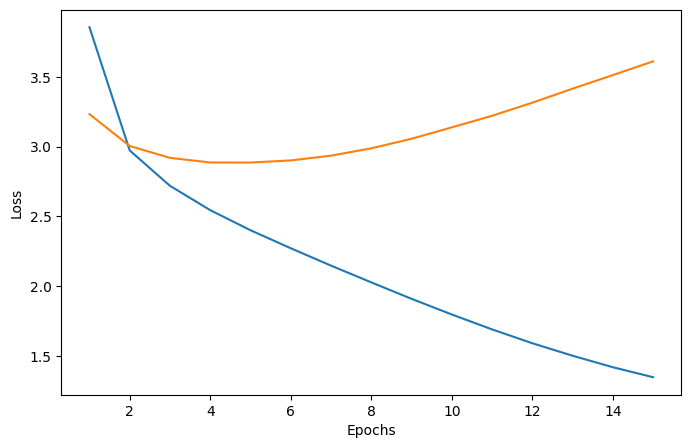

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,5))

plt.plot(
    range(1 , EPOCHS + 1),
    train_losses,
    label = "Train loss"
)

plt.plot(
    range(1 , EPOCHS + 1),
    val_losses,
    label = "Validation Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")


In [ ]:
def generate_caption(model , image , tokenizer , prompt = "A photo of" , max_new_tokens = 10):

  model.eval()

  with torch.no_grad():
    vision_output = model.vision_encoder(image.unsqueeze(0).to(device))

    image_features = vision_output.last_hidden_state[: , 0]

    image_embeddings = model.image_projector(image_features)

    image_embeddings = (
        image_embeddings.unsqueeze(1)
    )

    prompt_ids = tokenizer(
        prompt,
        add_special_tokens = True
    )["input_ids"]

    generated_ids = torch.tensor(
        prompt_ids,
        dtype = torch.long,
        device=device
    ).unsqueeze(0)


    for _ in range(max_new_tokens):

      text_embeddings = (model.llama.model.embed_tokens(generated_ids))

      input_embeds = torch.cat([image_embeddings , text_embeddings] , dim = 1)

      attention_mask = torch.ones(
          input_embeds.shape[:2],
          dtype = torch.long,
          device = device
      )

      outputs = model.llama(
      inputs_embeds = input_embeds,
      attention_mask= attention_mask
      )

      next_token_logits = (
          outputs.logits[ :, -1 , :]
      )

      next_token_ids = torch.argmax(
          next_token_logits,
          dim = -1,
          keepdim = True
      )

      generated_ids = torch.cat(
          [generated_ids , next_token_ids],dim = 1
      )

      if (
          next_token_ids.item() == tokenizer.eos_token_id
      ):
        break


  generated_caption_ids = (generated_ids[0][len(prompt_ids):])

  caption = tokenizer.decode(
      generated_caption_ids.tolist(),
      skip_special_tokens = True
  )

  return caption


In [ ]:
import random

model.eval()

# Get unique validation images
samples = val_df["image"].unique()

# Randomly select 20 images
samples = random.sample(list(samples), 1000)

results = []

for image_name in samples:

    # Get one row for image path
    row = val_df[val_df["image"] == image_name].iloc[0]

    image = Image.open(row["image_path"]).convert("RGB")

    image_tensor = image_transform(image).to(device)

    generated = generate_caption(
        model,
        image_tensor,
        tokenizer,
        prompt="A photo of",
        max_new_tokens=20
    )

    # Get all 5 reference captions for this image
    references = val_df[
        val_df["image"] == image_name
    ]["caption"].tolist()

    results.append({
        "image": image_name,
        "generated": generated,
        "references": references
    })


# Display results
for i, result in enumerate(results):

    print("=" * 80)

    print(f"IMAGE: {result['image']}")

    print(f"GENERATED: {result['generated']}")

    print("REFERENCES:")

    for ref in result["references"]:
        print(f" - {ref}")

IMAGE: 3718007650_e5930b4509.jpg
GENERATED: A man in a black shirt and a woman in a black shirt are sitting on a ben
REFERENCES:
 - A girl with a black dress and big white bow stands with her back to the camera .
 - many people gather outside .
 - People stand outside watching something .
 - People with costumes are gathered in a wooded area looking the same direction .
 - The back of a woman in costume ; little girl looks at her
IMAGE: 2904997007_23d4b94101.jpg
GENERATED: A man in a red shirt and a woman in a red shirt are sitting on a ben
REFERENCES:
 - A child leaping toward a red bed .
 - A little boy jumps high off his bed .
 - A little boy jumps off of a bunk bed onto another bed .
 - A small boy jumps from a bunk bed onto a single bed .
 - a young boy jumping from a bunk bed on a smaller bed .
IMAGE: 757133580_ba974ef649.jpg
GENERATED: A man in a red jacket and blue jacket is snowboarding . " . " .
REFERENCES:
 - A child at the top of a fake rock wall .
 - A child climbs a rock 

In [ ]:
generated_captions = [
    r["generated"].strip().lower()
    for r in results
]

print("Total captions:", len(generated_captions))
print("Unique captions:", len(set(generated_captions)))

Total captions: 1000
Unique captions: 92


In [ ]:
from collections import Counter

all_words = []
all_bigrams = []


for caption in generated_captions:
  words = caption.split()

  all_words.extend(words)

  all_bigrams.extend(zip(words , words[1:]))

distinct1 = (len(set(all_words)))/(len(all_words))
distinct2 = (len(set(all_bigrams)))/(len(all_bigrams))

print(f"Distinct_1 : {distinct1:.4f}")
print(f"Distinct_2 : {distinct2}")

Distinct_1 : 0.0057
Distinct_2 : 0.012732846026880454


In [ ]:
caption_counts = Counter(generated_captions)

print("\nTop generated captions:")

for caption, count in caption_counts.most_common(10):
    print(f"{count:4d} : {caption}")


Top generated captions:
 108 : a man in a red shirt is standing on a rocky shore . while a man looks on
  96 : a man in a blue shirt is standing on a rocky shore . while a black dog is
  95 : a man in a red shirt is standing in a crowd of people . " . " . "
  63 : a man in a blue shirt is standing on a rocky shore . while a man looks on
  51 : a man in a red shirt and a woman in a red shirt are sitting on a ben
  49 : a man in a red shirt and a woman in a black shirt are sitting on a ben
  47 : a man in a red shirt and tie is standing on a stage with a woman in a black
  39 : a man in a red jacket and blue cap is standing on a rocky shore . while a
  34 : a man in a red shirt is standing in a crowd of people . " balloon .
  33 : a man in a red shirt is standing in a crowd of people . " ? " . "


In [ ]:
def repetition_ratio(caption):

    words = caption.split()

    if len(words) <= 1:
        return 0.0

    repeated = sum(
        1 for i in range(1, len(words))
        if words[i] == words[i-1]
    )

    return repeated / (len(words) - 1)


repetition_scores = [
    repetition_ratio(caption)
    for caption in generated_captions
]

print(
    "Average repetition ratio:",
    sum(repetition_scores) / len(repetition_scores)
)

Average repetition ratio: 0.007131191950464397
